<a href="https://colab.research.google.com/github/wan-chtvlv/spatial-coastal-ses/blob/main/A1_2_tutorial_performing_spatial_queries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A1-2 Tutorial from SpatialThoughts
GeoPandas - Performing Spatial Queries
https://www.geopythontutorials.com/notebooks/geopandas_spatial_query.html

# Setup

In [14]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
data_folder = './A1-2-data/'
output_folder = './A1-2-output/'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)
def download(url):
    filename = os.path.join(data_folder, os.path.basename(url))
    if not os.path.exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)

data_url = 'https://github.com/spatialthoughts/geopython-tutorials/releases/download/data/'

download(data_url + 'bars_and_pubs_with_patron_capacity.csv')
download(data_url + 'metro_stations_accessbility.zip')

In [15]:
csv_file = 'bars_and_pubs_with_patron_capacity.csv'
csv_path = os.path.join(data_folder, csv_file)
barspubs_df = pd.read_csv(csv_path)
barspubs_df.iloc[:, :]

,Census year,Block ID,Property ID,Base property ID,Street address,CLUE small area,Trading name,Number of patrons,x coordinate,y coordinate,Location
0,2002,247,106238,106238,192-202 Lygon Street,Carlton,Players On Lygon,200,144.967052,-37.802459,"(-37.80245924, 144.9670522)"
1,2002,252,106244,106244,160-162 Lygon Street,Carlton,Bar Centrale,500,144.966770,-37.803442,"(-37.80344164, 144.9667699)"
2,2006,16,104018,104018,172-192 Flinders Street,Melbourne (CBD),Purple Emerald,110,144.968543,-37.816639,"(-37.81663851, 144.9685429)"
3,2002,214,106186,106186,414-422 Lygon Street,Carlton,Percys Bar & Bistro,120,144.967813,-37.796946,"(-37.79694555, 144.9678126)"
4,2008,76,589841,105749,221 Little Lonsdale Street,Melbourne (CBD),JWow Bar,100,144.965703,-37.810658,"(-37.810658, 144.9657034)"
...,...,...,...,...,...,...,...,...,...,...,...
3333,2017,85,105746,105746,183-265 La Trobe Street,Melbourne (CBD),Equinox Bar Restaurant,80,144.963019,-37.810733,"(-37.81073331, 144.9630189)"
3334,2017,74,104662,104662,106-112 Hardware Street,Melbourne (CBD),Nieuw Amsterdam,200,144.960680,-37.812136,"(-37.81213605, 144.9606805)"
3335,2017,268,108154,108153,49 Rathdowne Street,Carlton,Epocha Restaurant,124,144.968594,-37.805787,"(-37.80578725, 144.9685944)"
3336,2017,104,104085,104085,167-175 Franklin Street,Melbourne (CBD),Disco Bar,200,144.959154,-37.808960,"(-37.80895967, 144.9591538)"


In [16]:
barspubs_df = barspubs_df.sort_values('Property ID')
barspubs_df.iloc[:, :5]

,Census year,Block ID,Property ID,Base property ID,Street address
2553,2015,103,100160,100160,196-200 A'Beckett Street
2201,2010,103,100160,100160,196-200 A'Beckett Street
1461,2009,103,100160,100160,196-200 A'Beckett Street
709,2011,103,100160,100160,196-200 A'Beckett Street
1225,2013,103,100160,100160,196-200 A'Beckett Street
...,...,...,...,...,...
2016,2014,1105,628712,628712,717-731 Collins Street
2832,2016,66,635138,635138,13 Heffernan Lane
3069,2017,66,635138,635138,13 Heffernan Lane
3228,2017,270,664626,104468,230 Grattan Street


In [19]:
# Keeping only the first entries of different PropertyIDs
barspubs_df = barspubs_df.drop_duplicates(subset=['Property ID'], keep='first')
# The coordinates are in the last 5 columns of this dataframe
barspubs_df.iloc[:, :]

,Census year,Block ID,Property ID,Base property ID,Street address,CLUE small area,Trading name,Number of patrons,x coordinate,y coordinate,Location
2553,2015,103,100160,100160,196-200 A'Beckett Street,Melbourne (CBD),Nomads Industry Backpackers,200,144.957445,-37.809985,"(-37.80998494, 144.9574447)"
1087,2011,409,100441,100441,118-126 Ireland Street,West Melbourne (Residential),Railway Hotel,241,144.942118,-37.806054,"(-37.80605366, 144.9421177)"
121,2002,315,100514,100514,204-206 Arden Street,North Melbourne,North Melbourne Football Club Social Club,210,144.941312,-37.799055,"(-37.79905531, 144.9413118)"
1501,2009,33,100727,100727,5-9 Bank Place,Melbourne (CBD),Mitre Tavern,300,144.960311,-37.816805,"(-37.81680457, 144.9603112)"
462,2008,33,100730,100730,12-16 Bank Place,Melbourne (CBD),Melbourne Savage Club,30,144.960577,-37.816545,"(-37.81654467, 144.9605765)"
...,...,...,...,...,...,...,...,...,...,...,...
864,2011,2391,616966,616966,2 Boundary Road,North Melbourne,Vodka Locka & Red Leaf Restaurant,40,144.939233,-37.795318,"(-37.79531826, 144.9392333)"
1514,2010,1110,620312,593737,23-37 Star Crescent,Docklands,Harbour Town Hotel,498,144.937830,-37.813150,"(-37.81315031, 144.9378299)"
3028,2016,1105,628712,628712,717-731 Collins Street,Docklands,Bar Nicional,75,144.950093,-37.820687,"(-37.82068699, 144.9500934)"
2832,2016,66,635138,635138,13 Heffernan Lane,Melbourne (CBD),Union Electric,72,144.966591,-37.811802,"(-37.81180178, 144.9665913)"


In [81]:
# Create geometries from the lat lon data
geometry = gpd.points_from_xy(barspubs_df['x coordinate'],barspubs_df['y coordinate'])
barspubs_gdf = gpd.GeoDataFrame(barspubs_df, crs='EPSG:7855', geometry=geometry) #Tutorial had it projected for CRS='EPSG:4326', then reprojected it for Melbourne. I'm changing it here instead.
barspubs_gdf.crs
barspubs_gdf.total_bounds


array([144.9286331 , -37.84752524, 144.9856254 , -37.78289944])

Note from ***Gemini*** after unsuccessfully trying to reproject the metrostations_gdf layer.
---
"When projecting from EPSG:4326 (WGS 84, in degrees) to EPSG:7855 (GDA2020 / MGA zone 55, in meters), your total_bounds will look drastically different because the numerical values change from latitude/longitude values to large easting/northing coordinates."

*Gemini* suggests doing an axis order inversion:
"In the newer PROJ/GDAL backends used by GeoPandas, EPSG:4326 strictly enforces the traditional standard of (Latitude, Longitude) axis order, whereas many shapefiles and data pipelines store coordinates as (Longitude, Latitude) (or X, Y).If your data coordinates are ordered as [Longitude, Latitude], GeoPandas might read the longitude as latitude. When it tries to project a longitude like 145.0 as a latitude (which can only go up to 90.0), the math breaks or distorts completely."

In [64]:
# Get metrostation data
zip_file = 'metro_stations_accessbility.zip'
zip_path = os.path.join('zip://', data_folder, zip_file)
metrostations_gdf = gpd.read_file(zip_path)
metrostations_gdf.total_bounds
metrostations_gdf.crs
metrostations_gdf


,station,pids,he_loop,lift,geometry
0,Alamein,No,No,No,POINT (145.07956 -37.86884)
1,Albion,Dot Matrix,No,No,POINT (144.82471 -37.77766)
2,Alphington,Dot Matrix,No,No,POINT (145.03125 -37.7784)
3,Altona,LCD,No,No,POINT (144.8306 -37.86725)
4,Anstey,No,No,No,POINT (144.96056 -37.7619)
...,...,...,...,...,...
214,Williams Landing,Dot Matrix,Yes,Yes,POINT (144.74719 -37.8701)
215,Aircraft,No,No,No,POINT (144.76081 -37.8666)
216,Flemington Racecourse,No,No,No,POINT (144.9072 -37.78759)
217,Showgrounds,No,No,No,POINT (144.91498 -37.78355)


In [85]:
# Extracting lat lon from the address location object created from the Nominatim function above.
metrostations_gdf['latitude'] = metrostations_gdf.geometry.y
metrostations_gdf['longitude'] = metrostations_gdf.geometry.x

geometry = gpd.points_from_xy(metrostations_gdf.latitude, metrostations_gdf.longitude)
metrostations_gdf = gpd.GeoDataFrame(metrostations_gdf, crs='EPSG:7855', geometry=geometry)
metrostations_gdf

,station,pids,he_loop,lift,geometry,latitude,longitude
0,Alamein,No,No,No,POINT (-37.869 145.08),-37.868843,145.079558
1,Albion,Dot Matrix,No,No,POINT (-37.778 144.825),-37.777656,144.824710
2,Alphington,Dot Matrix,No,No,POINT (-37.778 145.031),-37.778396,145.031251
3,Altona,LCD,No,No,POINT (-37.867 144.831),-37.867249,144.830604
4,Anstey,No,No,No,POINT (-37.762 144.961),-37.761898,144.960561
...,...,...,...,...,...,...,...
214,Williams Landing,Dot Matrix,Yes,Yes,POINT (-37.87 144.747),-37.870100,144.747194
215,Aircraft,No,No,No,POINT (-37.867 144.761),-37.866603,144.760809
216,Flemington Racecourse,No,No,No,POINT (-37.788 144.907),-37.787586,144.907196
217,Showgrounds,No,No,No,POINT (-37.784 144.915),-37.783552,144.914982


In [88]:
metrostations_gdf.total_bounds

array([-38.374052, 144.660913, -37.579391, 145.486511])

# Visualization

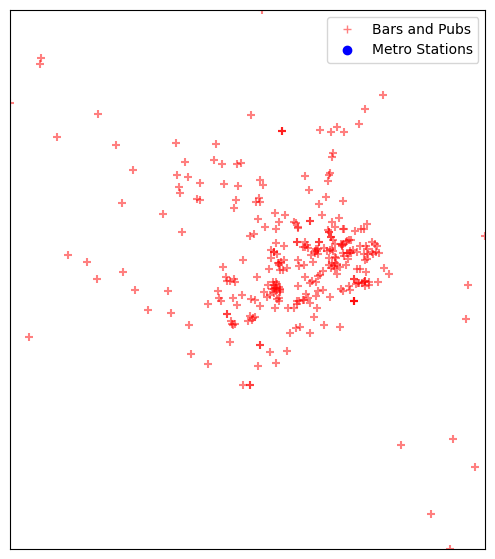

In [89]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(15,7) #This is a bit weird, tried changing the numbers but the fig size doesn't come out as expected: https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.set_size_inches.html
barspubs_gdf.plot(ax=ax, color='red', alpha=0.5, marker='+')
metrostations_gdf.plot(ax=ax, color='blue', alpha=0.5, marker='o')

minx, miny, maxx, maxy = barspubs_gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

legend_elements = [
    plt.plot([],[], color='red', alpha=0.5, marker='+', label='Bars and Pubs', ls='')[0],
    plt.plot([],[], color='blue', alpha=1, marker='o', label='Metro Stations', ls='')[0]]
ax.legend(handles=legend_elements, loc='upper right')
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.show()

# Buffer

In [51]:
radius = 500

buffer_geometry = metrostations_gdf.buffer(
    radius, resolution=5, cap_style=1, join_style=1, mitre_limit=2)
metrostations_gdf['geometry'] = buffer_geometry

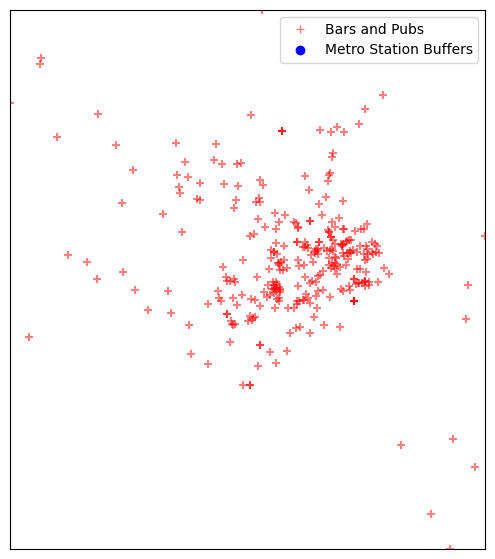

In [52]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(15,7)
barspubs_gdf.plot(ax=ax, color='red', alpha=0.5, marker='+')
metrostations_gdf.plot(ax=ax, facecolor='none', edgecolor='blue',  alpha=0.5, marker='o')

minx, miny, maxx, maxy = barspubs_gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

legend_elements = [
    plt.plot([],[], color='red', alpha=0.5, marker='+', label='Bars and Pubs', ls='')[0],
    plt.plot([],[], color='blue', alpha=1, marker='o', label='Metro Station Buffers', ls='')[0]]
ax.legend(handles=legend_elements, loc='upper right')
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.show()